# Universidad de Buenos Aires
# Aprendizaje Profundo - TP2
# Cohorte 22 - 5to bimestre 2025

El segundo TP comienza la semana de la clase 4 y la ventana de entrega estará abierta hasta las **23hs del viernes 28 de noviembre (hora de Argentina)**. La resolución del TP es **individual**. Pueden utilizar tanto los contenidos vistos en clase, como otra bibliografía externa. Si se toman ideas de fuentes externas deben ser correctamente citadas incluyendo el correspondiente link o página de libro.

ESTE TP2 EQUIVALE A UN TERCIO DE SU NOTA FINAL.

El formato de entrega debe ser un link a un notebook de google colab. Importante permitir acceso a gvilcamiza.ext@fi.uba.ar y **habilitar los comentarios, para poder darles el feedback**. Si no lo hacen así no se podrá dar el feedback respectivo por cada pregunta.

El envío **se realizará en el siguiente link de google forms: [link](https://forms.gle/kvD11QBVSHbHA8QDA)**. Tanto los resultados, gráficas, como el código y las explicaciones deben quedar guardados y visualizables en el colab.

**NO SE VALIDARÁN ENVÍOS POR CORREO, EL MÉTODO DE ENTREGA ES SOLO POR EL FORMS.**

**Consideraciones a tener en cuenta:**
- Se entregará 1 solo colab para este TP2.
- Renombrar el archivo de la siguiente manera: **APELLIDO-NOMBRE-DL-TP2-Co22.ipynb**
- Los códigos deben poder ejecutarse.
- **IMPORTANTE:** Los resultados, cómo el código, los gráficos, los prints y las explicaciones deben quedar guardados y visualizables en el mismo notebook.
- **Prestar mucha atención a cada consigna, responder las preguntas justo debajo del enunciado que corresponda.**
- Solo se revisarán los trabajos que hayan sido enviados por el forms.

# CASO: Adult Census Income

El objetivo del trabajo es construir un modelo de clasificación binaria que, a partir de los datos censales de diferentes hogares, determine si un individuo pertenece al grupo de mayores o de menores ingresos. Para ello, se empleará un conjunto de variables demográficas, laborales y socioeconómicas que describen las características de cada persona. El estudio debe incluir el análisis exploratorio del dataset, la selección y justificación de las transformaciones más adecuadas para cada variable, la construcción de modelos basados tanto en técnicas de codificación tradicionales como también en representaciones avanzadas mediante embeddings, y la comparación final del desempeño obtenido por cada enfoque.

**Para este caso de estudio, consideraremos como variable de alta cardinalidad a las que tengan 10 o más valores únicos.**


Encontrarán el dataset en el siguiente enlace de drive: [link](https://drive.google.com/drive/folders/1S-usUXkJP6OdzUS0zdC5CW-XqegiXzln?usp=sharing)

Está compuesto por los siguientes features:
- **age**: Edad del individuo expresada en años.

- **workclass**: Tipo de empleador o relación laboral del individuo. Describe si trabaja en el sector privado, gobierno estatal, local, federal, por cuenta propia, sin remuneración, etc.

- **education**: Nivel educativo alcanzado. Incluye categorías como secundaria completada, licenciatura, maestría, doctorado, etc.

- **marital-status**: Estado civil (casado, nunca casado, divorciado, viudo, etc.).

- **occupation**: Tipo de ocupación o área laboral, donde se incluye ventas, servicios de protección, técnicos, gerencia ejecutiva, fuerzas armadas, etc.

- **relationship**: Relación del individuo con el jefe del hogar como esposo, esposa, hijo propio, pariente, no familiar, etc.

- **race**: Autoidentificación racial como blanca, negra, indígena, asiática, isleños del Pacífico, entre otras.

- **sex**: Sexo biológico del individuo (masculino o femenino).

- **capital-gain**: Ingresos obtenidos por ganancia de capital (por ejemplo, venta de acciones o propiedades).

- **capital-loss**: Pérdidas declaradas por capital.

- **hours-per-week**: Cantidad de horas trabajadas por semana.

- **native-country**: País de nacimiento del individuo. Incluye Estados Unidos y una lista amplia de países del mundo.

- **income (target)**: Clasificación binaria que indica si el ingreso anual del individuo es mejor o igual a 50K o mayor a 50K.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import numpy as np
import sklearn

## a) Análisis exploratorio de los datasets (2 puntos)

- Realizar un EDA apoyado en gráficas adecuadas y coherentes para el caso de estudio.
- Analizar detalladamente los valores únicos de cada variable categórica e identificar su nivel de cardinalidad.
- Justificar de manera detallada el tipo de transformación que se le asignará a cada variable, en especial a las categóricas. **Dependiendo de su cardinalidad, su contexto y/o lógica interna de orden**, podrán transformarse mediante label/ordinal encoding, one-hot encoding o mediante una capa de embeddings dentro del modelo.
- No es necesario aplicar la misma transformación para todas las variables categóricas. El dataset puede (y debe) incluir diferentes tipos de transformaciones según las características de cada variable.
- Redactar explícitamente la decisión final adoptada para cada variable y su justificación correspondiente.

In [2]:
df = pd.read_csv('adult_train.csv')
df.describe()

,age,capital-gain,capital-loss,hours-per-week
count,30162.000000,30162.000000,30162.000000,30162.000000
mean,38.437902,1092.007858,88.372489,40.931238
std,13.134665,7406.346497,404.298370,11.979984
min,17.000000,0.000000,0.000000,1.000000
25%,28.000000,0.000000,0.000000,40.000000
50%,37.000000,0.000000,0.000000,40.000000
75%,47.000000,0.000000,0.000000,45.000000
max,90.000000,99999.000000,4356.000000,99.000000


A continuación tenemos histogramas para todas las variables.

En cuanto a la distrbución de las variables categóricas podemos notar:
- `workclass`: la mayoría trabaja en el sector privado. Se tiene una cantidad casi nula de personas sin paga.
- `education`: la mayoría es graduada de high-school, luego se tiene some-college y bachelor. El resto tiene frecuencia bastante menor y bastante uniforme entre sí.
- `marital-status`: se tiene una primer mayoría casada, seguida por los individuos que nunca se casaron, y luego los divorciados. El resto de categorías se encuentran menos representadas.
- `ocupation`: se observan 2 grupos con mayor y menor frecuencia respectivamente. Además `armed-forces` y `priv-house-serv` se encuentran aún menos representadas que el 2do grupo.
- `relationship`: la mayoría es esposo, con en segundo lugar sin familia. Luego se tienen frecuencias decrecientes.
- `race`: la raza preponderante es blanco, y el resto están representados en medidas bastante menores.
- `sex`: la mayoría son hombres. Esto tiene sentido teniendo en cuenta que en `relationship` se tiene esposo con la mayor frecuencia y esposa con la menor frecuencia, y que casado es el `martial-status` más frecuente.
- `native-country`: Estados Unidos es el país más representado con diferencia. El resto de países están representados en mucho menor medida.

Si anaizamos las métricas básicas de las variables numéricas, podemos ver que:
- La media de edad es 38 años, con el cuantil 75 estando a los 47 años. 
- Tanto las ganancias como pérdidas de cpaital presentan un cuantil 75 de 0, es decir que al menos el 75% de los individuos no tuvieron ni ganancia ni pérdida de capital. Además el tope de ganancia de capital es de 99999, lo cual parecería indicar que se tenía un valor máximo admitido a la hora de tomar estos datos. Además en el histograma se ve una alta concentración en estos valores (*nota: el histograma no tiene graficados los valores 0 ya que es un valor demasiado repetido y no se logra percibir como están representados los valores >0*). Esto último podría indicarnos que sería más representativo discretizar esta variable en una categórica ordinal, teniendo >99999 como ganancia de capital alta.
- En las horas trabajadas por semana se ve que, esperablemente, la media está en 40 horas por semana, y además viendo el histograma vemos que se tiene una alta densidad en ese valor de horas trabajadas.

Consideremos ahora la información aportada por la diferenciación entre el ingreso:
- En la edad vemos una distribución más centrada en 35-45 años para el ingreso mayor, teniendo una distrbución más asimétrica izquierda para ingresos menores.
- En la educación se observa que Bachelors, Masters, Prof-school y Doctorate tienen mayor proporción de ingresos mayores que el resto de categorías.
- En el estado marital, se ve que los casados tienen una proporción mucho mayor de ingresos mayores.
- En la ocupación, se tiene mayor proporción de ingresos mayores para los `Exec-managerial` y `Prof-speciality`.
- En la relación, los epsposos y las esposas tienen mayor proporción de ingresos mayores que el resto de relaciones.
- En la ganancia de capital se ve una tendencia a tener mayores ingresos a mayores ganancias de capital. *Nota: también se ve una proporción mayor de mayores ingresos a ganancias de capital nula*



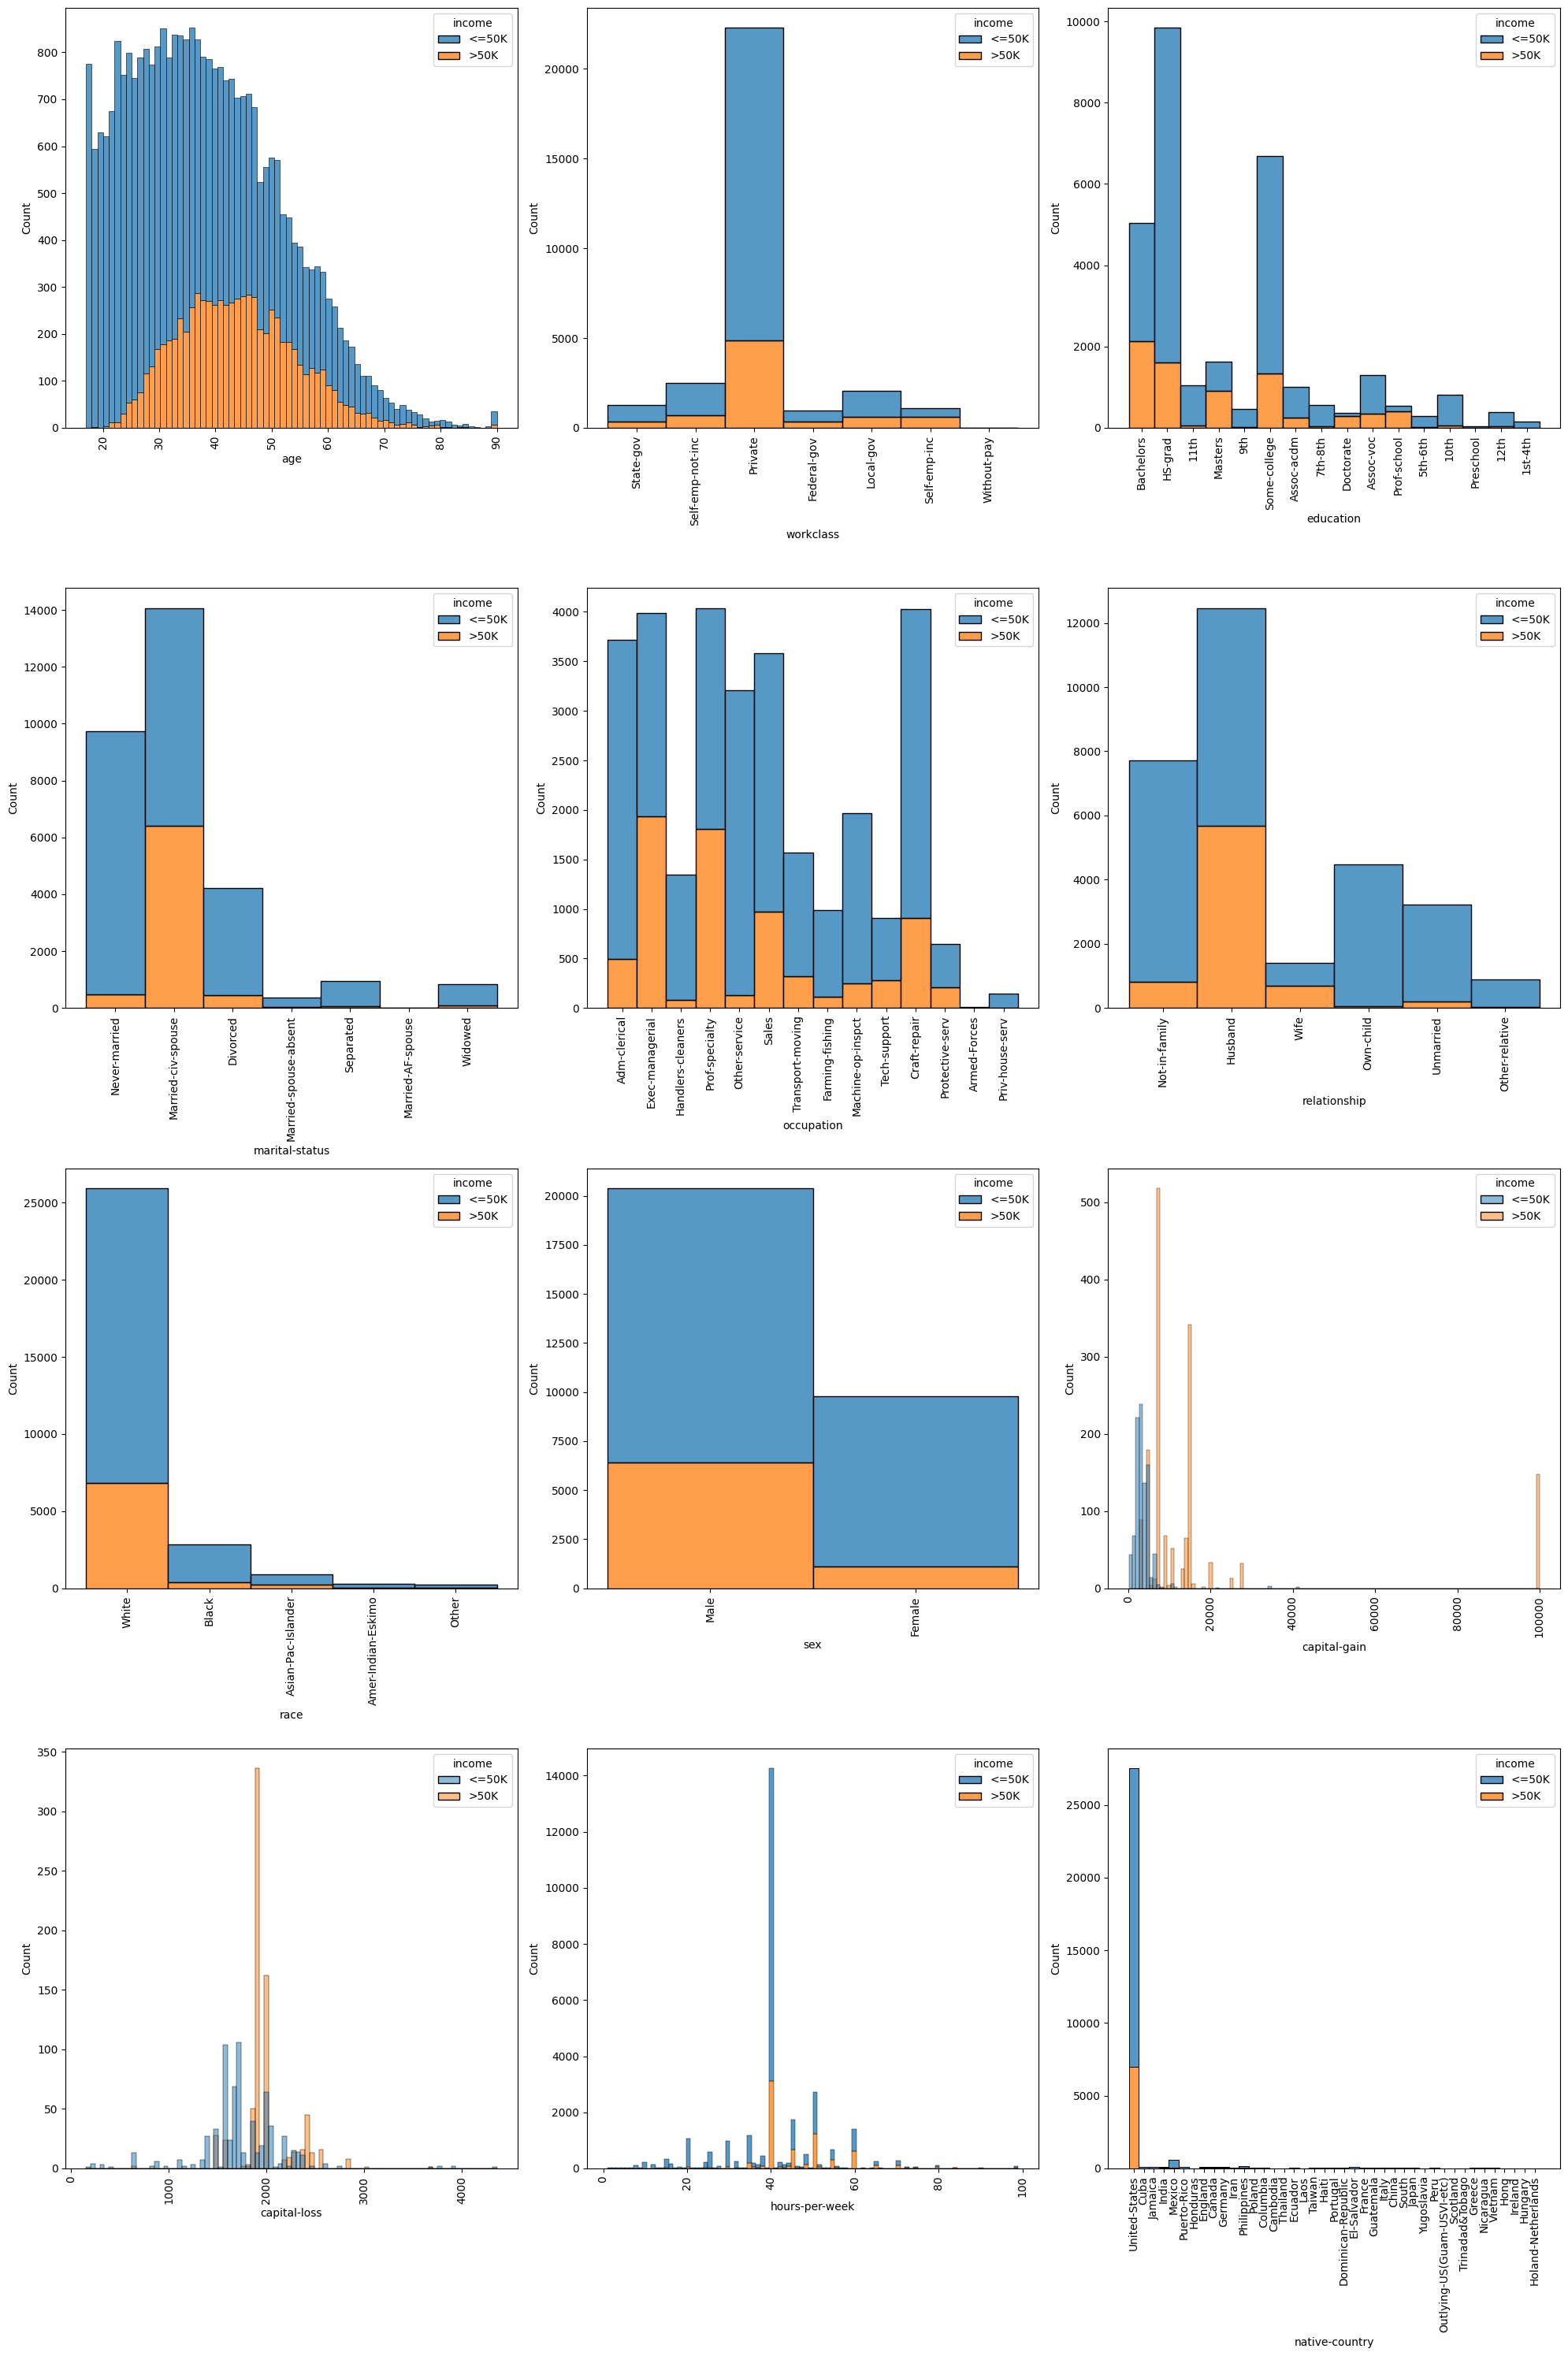

workclass: 7 valores únicos
education: 16 valores únicos
marital-status: 7 valores únicos
occupation: 14 valores únicos
relationship: 6 valores únicos
race: 5 valores únicos
sex: 2 valores únicos
native-country: 41 valores únicos


In [3]:
fig, axs = plt.subplots(4,3,figsize=(20,30))
for idx, col in enumerate(['age','workclass','education','marital-status','occupation','relationship','race','sex','capital-gain','capital-loss','hours-per-week','native-country']):
    if col in ['age', 'hours-per-week']:
        sns.histplot(data=df, x=col, ax=axs[idx//3][idx%3], bins=len(df[col].value_counts()), hue='income', multiple='stack')
    elif col in ['capital-gain', 'capital-loss']:
        sns.histplot(data=df[ df[col]!= 0], x=col, ax=axs[idx//3][idx%3], bins=len(df[col].value_counts()), hue='income')
        # sns.histplot(data=df, x=col, ax=axs[idx//3][idx%3], bins=len(df[col].value_counts()), hue='income', multiple='stack')
        # axs[idx//3][idx%3].set_yscale('log')
    else:
        # sns.countplot(data=df, x=col, ax=axs[idx//3][idx%3], hue='income')
        sns.histplot(data=df, x=col, ax=axs[idx//3][idx%3], hue='income', multiple='stack')
    axs[idx//3][idx%3].tick_params(axis='x', rotation=90)
plt.tight_layout() 
plt.show()

df.describe()

for idx, col in enumerate(['workclass','education','marital-status','occupation','relationship','race','sex','native-country']):
    print(f"{col}: {len(df[col].value_counts())} valores únicos")

In [4]:
df['native-country'].value_counts()

native-country
United-States                 27504
Mexico                          610
Philippines                     188
Germany                         128
Puerto-Rico                     109
Canada                          107
El-Salvador                     100
India                           100
Cuba                             92
England                          86
Jamaica                          80
South                            71
Italy                            68
China                            68
Dominican-Republic               67
Vietnam                          64
Guatemala                        63
Japan                            59
Columbia                         56
Poland                           56
Haiti                            42
Iran                             42
Taiwan                           42
Portugal                         34
Nicaragua                        33
Peru                             30
Greece                           29
France       

In [5]:
df_val = pd.read_csv('adult_val.csv')
df_val.head()

,age,workclass,education,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,11th,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,HS-grad,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,Assoc-acdm,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,Some-college,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,34,Private,10th,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K


In [52]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder, StandardScaler
df_encoded = df[['age']].copy()

# el sexo lo encodeamos con one-hot encoding binario
sex_encoder = OneHotEncoder(drop='if_binary')
df_encoded['sex'] = sex_encoder.fit_transform(df['sex'].array.reshape(-1,1)).toarray()

# para las variables numéricas de ganancia y pérdida de capital y horas por semana usaremos un standard scaler
# capital-gain
cap_gain_encoder = StandardScaler()
df_encoded['capital-gain'] = cap_gain_encoder.fit_transform(df['capital-gain'].array.reshape(-1,1))
# capital-loss
cap_loss_encoder = StandardScaler()
df_encoded['capital-loss'] = cap_loss_encoder.fit_transform(df['capital-loss'].array.reshape(-1,1))
# hours-per-week 
hours_encoder = StandardScaler()
df_encoded['hours-per-week'] = hours_encoder.fit_transform(df['hours-per-week'].array.reshape(-1,1))

# la educación la encodeamos con ordinal encoding
# primero vamos a agrupar algunos tipos de educación
def group_eds(ed):
    if ed == 'Assoc-voc' or ed == 'Assoc-acdm':
        return 'Associate'
    elif ed in ['Preschool', '1st-4th', '5th-6th', '7th-8th', '9th', '10th', '11th', '12th']:
        return 'No-Diploma'
    else:
        return ed
df_encoded['education'] = df['education'].map(group_eds)
# ahora si aplicamos ordinal encoding
ed_encoder = OrdinalEncoder(categories=[['No-Diploma', 'HS-grad', 'Some-college', 'Associate', 'Bachelors', 'Masters', 'Prof-school', 'Doctorate']])
df_encoded['education'] = ed_encoder.fit_transform(df_encoded['education'].array.reshape(-1,1))

# ahora encodeamos las variables que no tiene cardinalidad lo suficientemente alta como para considerar embeddings
# workclass
# se podría juntar los trabajadores estatales en 1 única variable y los self-employed en otra. Pero por ahora ahora one-hot encoding normal
workclass_encoder = OneHotEncoder()
df_encoded[df['workclass'].unique()] = workclass_encoder.fit_transform(df['workclass'].array.reshape(-1,1)).toarray()

# marital-status
marital_status_encoder = OneHotEncoder()
df_encoded[df['marital-status'].unique()] = marital_status_encoder.fit_transform(df['marital-status'].array.reshape(-1,1)).toarray()

# relationship
relationship_encoder = OneHotEncoder()
df_encoded[df['relationship'].unique()] = relationship_encoder.fit_transform(df['relationship'].array.reshape(-1,1)).toarray()

# race
race_encoder = OneHotEncoder()
df_encoded[df['race'].unique()] = race_encoder.fit_transform(df['race'].array.reshape(-1,1)).toarray()

# las variables a las que le haremos embedding serán occupation y native-country
# previo al embedding la debemos convertir en números para que la pueda tomar de input la red neuronal
# para ello usamos un label encoding
occupation_encoder = LabelEncoder()
df_encoded['occupation'] = occupation_encoder.fit_transform(df['occupation'].array.ravel())
len_occupations = len(df_encoded['occupation'].unique())
print(len_occupations)

country_encoder = LabelEncoder()
df_encoded['native-country'] = country_encoder.fit_transform(df['native-country'].array.ravel())
len_countries = len(df_encoded['native-country'].unique())
print(len_countries)

# el income lo encodeamos con ordinal encoding
income_encoder = OrdinalEncoder(categories=[['<=50K', '>50K']])
df_encoded['income'] = income_encoder.fit_transform(df['income'].array.reshape(-1,1))

df_encoded

14
41


,age,sex,capital-gain,capital-loss,hours-per-week,education,State-gov,Self-emp-not-inc,Private,Federal-gov,...,Unmarried,Other-relative,White,Black,Asian-Pac-Islander,Amer-Indian-Eskimo,Other,occupation,native-country,income
0,39,1.0,0.146092,-0.218586,-0.077734,4.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,38,0.0
1,50,1.0,-0.147445,-0.218586,-2.331531,4.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3,38,0.0
2,38,1.0,-0.147445,-0.218586,-0.077734,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,5,38,0.0
3,53,1.0,-0.147445,-0.218586,-0.077734,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,5,38,0.0
4,28,0.0,-0.147445,-0.218586,-0.077734,4.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,9,4,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30157,27,0.0,-0.147445,-0.218586,-0.244682,3.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,12,38,0.0
30158,40,1.0,-0.147445,-0.218586,-0.077734,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,6,38,1.0
30159,58,0.0,-0.147445,-0.218586,-0.077734,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0,38,0.0
30160,22,1.0,-0.147445,-0.218586,-1.747213,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,38,0.0


## b) Diseño y entrenamiento de un modelo con embeddings (3 puntos)

- Implementar las transformaciones definidas en el punto anterior e incorporarlas al flujo de entrenamiento.
- El modelo debe incluir, como mínimo, una capa de embedding para representar alguna de las variables categóricas.
- La elección de la dimensión del o los embeddings queda a criterio del estudiante, pero debe estar correctamente fundamentada. Recuerden que no es obligatorio que todos los embeddings tengan la misma dimensión.
- La configuración arquitectónica (número de capas, neuronas por capa, función de activación) es de libre elección.
- Incluir dropout en las capas ocultas de la red.
- Utilizar Adam o alguna de sus variantes como optimizador.
- Seleccionar la función de costo apropiada entre Binary CrossEntropyLoss o Categorical CrossEntropyLoss, según la formulación del problema.
- Mostrar las curvas de accuracy vs epoch y F1 macro vs epoch para los sets de entrenamiento y validación.
- Presentar un classification report generado con sklearn.
- Presentar una matriz de confusión absoluta y otra normalizada por fila, correspondientes al set de validación.

In [53]:
from torch.utils.data import DataLoader, Dataset
from torch import nn
from collections import OrderedDict

class IncomeDataset(Dataset):
    def __init__(self, data):
        self.x = torch.tensor(data.drop(['occupation', 'native-country', 'income'], axis=1).values, dtype=torch.long)
        self.occupation = torch.tensor(data['occupation'].values, dtype=torch.long)
        self.country = torch.tensor(data['native-country'].values, dtype=torch.long)
        self.income = torch.tensor(data['income'].values, dtype=torch.float32)
    def __len__(self):
        return self.x.shape[0]
    def __getitem__(self, index):
        return self.x[index], self.occupation[index], self.country[index], self.income[index]

class NNetModel(nn.Module):
    def __init__(self, occupations, countries, x_shape, n_per_layer=128, layers=4, emb_dim=64, p=0.1):
        super().__init__()
        # definir los embeddings de occupation y countries
        self.ocuppation_embeddings = nn.Embedding(occupations, emb_dim)
        nn.init.normal_(self.ocuppation_embeddings.weight, std=0.1)
        self.countries_embeddings = nn.Embedding(countries, emb_dim)
        nn.init.normal_(self.countries_embeddings.weight, std=0.1)

        # definamos la red
        # capa de input
        network_order = [
            ('input_drop', nn.Dropout(p)),
            ('input', nn.Linear(emb_dim * 2 + x_shape - 3, n_per_layer)),
            ('input_act', nn.LeakyReLU())
        ]
        # capas ocultas
        for i in range(layers):
            network_order.append((f'drop_{i}', nn.Dropout(p)))
            network_order.append((f'layer_{i}', nn.Linear(n_per_layer, n_per_layer)))
            network_order.append((f'act_{i}', nn.LeakyReLU()))
        # capas de output
        network_order.append((f'drop_out', nn.Dropout(p)))
        network_order.append((f'output', nn.Linear(n_per_layer, 1)))
        network_order.append((f'out_act', nn.Sigmoid()))
        # instanciemos la red
        self.network = nn.Sequential(
            OrderedDict(network_order) 
        )
    
    def forward(self, x, occupation_values, countries_values):
        oc_values = self.ocuppation_embeddings(occupation_values)
        cou_values = self.countries_embeddings(countries_values)
        x = torch.cat([x, oc_values, cou_values], dim=1)
        y = self.network(x)
        return y.squeeze(1)


Epoch 1: loss=0.6757201572259267
Epoch 2: loss=0.6191234846909841
Epoch 3: loss=0.6107984522978465
Epoch 4: loss=0.6012789885203044
Epoch 5: loss=0.5839459637800852
Epoch 6: loss=0.5504950841267904
Epoch 7: loss=0.49929018716017404
Epoch 8: loss=0.45121850272019703
Epoch 9: loss=0.4237769067287445
Epoch 10: loss=0.4127313842376073
Epoch 11: loss=0.40647985339164733
Epoch 12: loss=0.3995921949545542
Epoch 13: loss=0.3958054612080256
Epoch 14: loss=0.3911097953716914
Epoch 15: loss=0.38446804881095886
Epoch 16: loss=0.3840910335381826
Epoch 17: loss=0.38377731839815776
Epoch 18: loss=0.3808382362127304
Epoch 19: loss=0.3782443175713221
Epoch 20: loss=0.3771758586168289
Epoch 21: loss=0.375535116593043
Epoch 22: loss=0.3736619253953298
Epoch 23: loss=0.3738944361607234
Epoch 24: loss=0.37308173179626464
Epoch 25: loss=0.3704559723536173
Epoch 26: loss=0.3708864827950796
Epoch 27: loss=0.36960294644037883
Epoch 28: loss=0.36658366123835245
Epoch 29: loss=0.3657135705153147
Epoch 30: loss=0

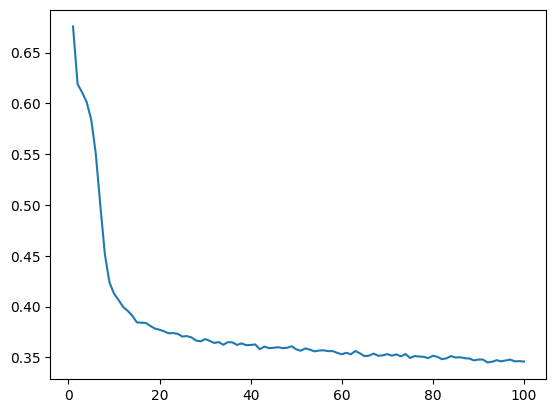

In [54]:
dataset = IncomeDataset(df_encoded)
print(dataset)
dataloader = DataLoader(dataset, batch_size=1024, shuffle=True)
print(dataloader)
device = 'cpu'
model = NNetModel(occupations=len_occupations, countries=len_countries, x_shape=df_encoded.shape[1], emb_dim=10, layers=3).to(device)

# criteria = nn.CrossEntropyLoss()
criteria = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

epochs = 100
loss_evol = []

for epoch in range(epochs):
    model.train()
    train_mse = []
    for xi, oc_i, count_i, yi in dataloader:
        yhat = model(xi, oc_i, count_i)
        loss = criteria(yhat, yi)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        train_mse.append(loss.item())
    loss_evol.append(np.mean(train_mse))
    print(f'Epoch {epoch+1}: loss={np.mean(train_mse)}')

plt.plot(range(1,epochs+1), loss_evol)
    

[2.4700256e-02 3.4417596e-01 1.7806858e-02 ... 3.2677490e-02 2.7613473e-04
 9.7032833e-01]


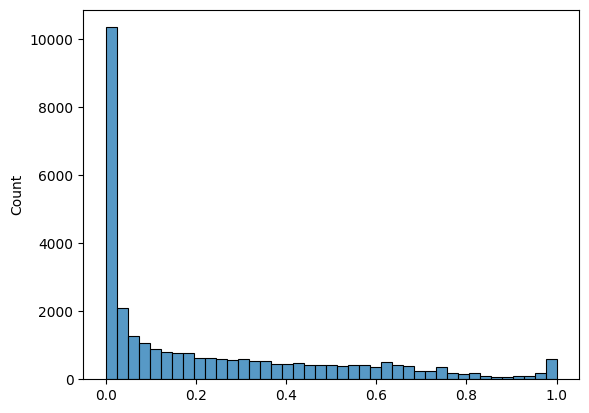

Farthest from random guess -> Best threshold = 0.25373944640159607
Nearest perfect model -> Best threshold = 0.2736853063106537


/tmp/ipykernel_6746/810737719.py:19: RuntimeWarning: invalid value encountered in sqrt
  geom_dist = np.sqrt((1-tpr)**2 - fpr**2)


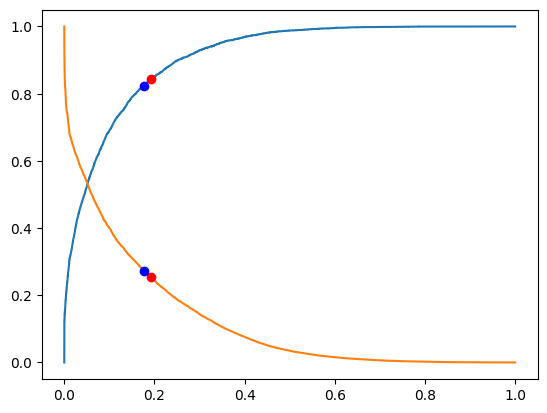

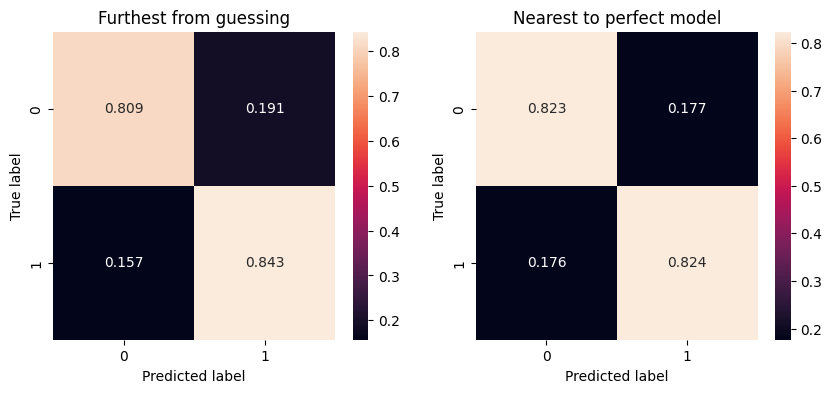

In [44]:
model.eval()
X = torch.tensor(df_encoded.drop(['occupation', 'native-country', 'income'], axis=1).values, dtype=torch.long)
occupation = torch.tensor(df_encoded['occupation'].values, dtype=torch.long)
country = torch.tensor(df_encoded['native-country'].values, dtype=torch.long)
with torch.no_grad():
    yhat = model(X, occupation, country).numpy()

print(yhat)
sns.histplot(yhat)
plt.show()

fpr, tpr, thr = sklearn.metrics.roc_curve(y_true=df_encoded['income'], y_score=yhat)

J = tpr - fpr
idx = np.argmax(J)
best_thr = thr[idx]
print(f"Farthest from random guess -> Best threshold = {best_thr}")

geom_dist = np.sqrt((1-tpr)**2 - fpr**2)
idx_2 = np.argmax(geom_dist)
best_thr_2 = thr[idx_2]
print(f"Nearest perfect model -> Best threshold = {best_thr_2}")

plt.plot(fpr, tpr)
plt.plot(fpr, thr)
plt.plot(fpr[idx], tpr[idx],'ro')
plt.plot(fpr[idx], thr[idx],'ro')
plt.plot(fpr[idx_2], tpr[idx_2],'bo')
plt.plot(fpr[idx_2], thr[idx_2],'bo')
plt.show()

thresh = 0.2
yhat_J = []
yhat_geom_dist = []
for i in range(yhat.shape[0]):
    if yhat[i]>=best_thr:
        yhat_J.append(1)
    else:
        yhat_J.append(0)
    if yhat[i]>=best_thr_2:
        yhat_geom_dist.append(1)
    else:
        yhat_geom_dist.append(0)

cm_J = sklearn.metrics.confusion_matrix(y_true=df_encoded['income'], y_pred=yhat_J, normalize='true')
cm_geom_dist = sklearn.metrics.confusion_matrix(y_true=df_encoded['income'], y_pred=yhat_geom_dist, normalize='true')
fig, axs = plt.subplots(1,2, figsize=(10,4))
# sns.heatmap(cm, annot=True, fmt=':.2f', ax=axs)
sns.heatmap(cm_J, annot=True, ax=axs[0], fmt='.3f')
axs[0].set_title('Furthest from guessing')
sns.heatmap(cm_geom_dist, annot=True, ax=axs[1], fmt='.3f')
axs[1].set_title('Nearest to perfect model')
for i in range(2):
    axs[i].set_ylabel('True label')
    axs[i].set_xlabel('Predicted label')

## c) Diseño y entrenamiento de un modelo sin embeddings (3 puntos)

- Entrenar un segundo modelo, aplicando one-hot encoding a todas las variables que en el punto b) fueron representadas mediante embeddings.
- Mantener exactamente la misma arquitectura del modelo anterior: igual número de capas, mismas neuronas, mismas funciones de activación y la misma probabilidad de dropout.
- Presentar las mismas métricas, visualizaciones y reportes que en el modelo con embeddings.

In [47]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder, StandardScaler
df_encoded = df[['age']].copy()

# el sexo lo encodeamos con one-hot encoding binario
sex_encoder = OneHotEncoder(drop='if_binary')
df_encoded['sex'] = sex_encoder.fit_transform(df['sex'].array.reshape(-1,1)).toarray()

# para las variables numéricas de ganancia y pérdida de capital y horas por semana usaremos un standard scaler
# capital-gain
cap_gain_encoder = StandardScaler()
df_encoded['capital-gain'] = cap_gain_encoder.fit_transform(df['capital-gain'].array.reshape(-1,1))
# capital-loss
cap_loss_encoder = StandardScaler()
df_encoded['capital-loss'] = cap_loss_encoder.fit_transform(df['capital-loss'].array.reshape(-1,1))
# hours-per-week 
hours_encoder = StandardScaler()
df_encoded['hours-per-week'] = hours_encoder.fit_transform(df['hours-per-week'].array.reshape(-1,1))

# la educación la encodeamos con ordinal encoding
# primero vamos a agrupar algunos tipos de educación
def group_eds(ed):
    if ed == 'Assoc-voc' or ed == 'Assoc-acdm':
        return 'Associate'
    elif ed in ['Preschool', '1st-4th', '5th-6th', '7th-8th', '9th', '10th', '11th', '12th']:
        return 'No-Diploma'
    else:
        return ed
df_encoded['education'] = df['education'].map(group_eds)
# ahora si aplicamos ordinal encoding
ed_encoder = OrdinalEncoder(categories=[['No-Diploma', 'HS-grad', 'Some-college', 'Associate', 'Bachelors', 'Masters', 'Prof-school', 'Doctorate']])
df_encoded['education'] = ed_encoder.fit_transform(df_encoded['education'].array.reshape(-1,1))

# ahora encodeamos las variables que no tiene cardinalidad lo suficientemente alta como para considerar embeddings
# workclass
# se podría juntar los trabajadores estatales en 1 única variable y los self-employed en otra. Pero por ahora ahora one-hot encoding normal
workclass_encoder = OneHotEncoder()
df_encoded[df['workclass'].unique()] = workclass_encoder.fit_transform(df['workclass'].array.reshape(-1,1)).toarray()

# marital-status
marital_status_encoder = OneHotEncoder()
df_encoded[df['marital-status'].unique()] = marital_status_encoder.fit_transform(df['marital-status'].array.reshape(-1,1)).toarray()

# relationship
relationship_encoder = OneHotEncoder()
df_encoded[df['relationship'].unique()] = relationship_encoder.fit_transform(df['relationship'].array.reshape(-1,1)).toarray()

# race
race_encoder = OneHotEncoder()
df_encoded[df['race'].unique()] = race_encoder.fit_transform(df['race'].array.reshape(-1,1)).toarray()

# las variables a las que le haremos embedding serán occupation y native-country
# previo al embedding la debemos convertir en números para que la pueda tomar de input la red neuronal
# para ello usamos un label encoding
occupation_encoder = OneHotEncoder()
df_encoded[df['occupation'].unique()] = occupation_encoder.fit_transform(df['occupation'].array.reshape(-1,1)).toarray()

country_encoder = OneHotEncoder()
df_encoded[df['native-country'].unique()] = country_encoder.fit_transform(df['native-country'].array.reshape(-1,1)).toarray()
print(len_countries)

# el income lo encodeamos con ordinal encoding
income_encoder = OrdinalEncoder(categories=[['<=50K', '>50K']])
df_encoded['income'] = income_encoder.fit_transform(df['income'].array.reshape(-1,1))

df_encoded

41


,age,sex,capital-gain,capital-loss,hours-per-week,education,State-gov,Self-emp-not-inc,Private,Federal-gov,...,Scotland,Trinadad&Tobago,Greece,Nicaragua,Vietnam,Hong,Ireland,Hungary,Holand-Netherlands,income
0,39,1.0,0.146092,-0.218586,-0.077734,4.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,50,1.0,-0.147445,-0.218586,-2.331531,4.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,38,1.0,-0.147445,-0.218586,-0.077734,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,53,1.0,-0.147445,-0.218586,-0.077734,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,28,0.0,-0.147445,-0.218586,-0.077734,4.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30157,27,0.0,-0.147445,-0.218586,-0.244682,3.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
30158,40,1.0,-0.147445,-0.218586,-0.077734,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
30159,58,0.0,-0.147445,-0.218586,-0.077734,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
30160,22,1.0,-0.147445,-0.218586,-1.747213,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [48]:
from torch.utils.data import DataLoader, Dataset
from torch import nn
from collections import OrderedDict

class NNetModel_noEmb(nn.Module):
    def __init__(self, x_shape, n_per_layer=128, layers=4,p=0.1):
        super().__init__()
        # definamos la red
        # capa de input
        network_order = [
            ('input_drop', nn.Dropout(p)),
            ('input', nn.Linear(x_shape - 1, n_per_layer)),
            ('input_act', nn.LeakyReLU())
        ]
        # capas ocultas
        for i in range(layers):
            network_order.append((f'drop_{i}', nn.Dropout(p)))
            network_order.append((f'layer_{i}', nn.Linear(n_per_layer, n_per_layer)))
            network_order.append((f'act_{i}', nn.LeakyReLU()))
        # capas de output
        network_order.append((f'drop_out', nn.Dropout(p)))
        network_order.append((f'output', nn.Linear(n_per_layer, 1)))
        network_order.append((f'out_act', nn.Sigmoid()))
        # instanciemos la red
        self.network = nn.Sequential(
            OrderedDict(network_order) 
        )
    
    def forward(self, x):
        y = self.network(x)
        return y.squeeze(1)


Epoch 1: loss=0.6157187044620513
Epoch 2: loss=0.5437710185845693
Epoch 3: loss=0.40955473482608795
Epoch 4: loss=0.37881657580534617
Epoch 5: loss=0.3670976916948954
Epoch 6: loss=0.3613521536191305
Epoch 7: loss=0.3548072298367818
Epoch 8: loss=0.3511008401711782
Epoch 9: loss=0.35177299082279206
Epoch 10: loss=0.34871220886707305
Epoch 11: loss=0.34742737412452696
Epoch 12: loss=0.34599384864171345
Epoch 13: loss=0.34495409230391183
Epoch 14: loss=0.34380408624807995
Epoch 15: loss=0.34340764085451764
Epoch 16: loss=0.34430189728736876
Epoch 17: loss=0.34399805466334027
Epoch 18: loss=0.34060885608196256
Epoch 19: loss=0.3412367065747579
Epoch 20: loss=0.3399373561143875
Epoch 21: loss=0.33835718433062234
Epoch 22: loss=0.34008069038391114
Epoch 23: loss=0.33846648236115773
Epoch 24: loss=0.3379645009835561
Epoch 25: loss=0.3338681330283483
Epoch 26: loss=0.3364502986272176
Epoch 27: loss=0.336012531320254
Epoch 28: loss=0.3353759656349818
Epoch 29: loss=0.33527773221333823
Epoch 30

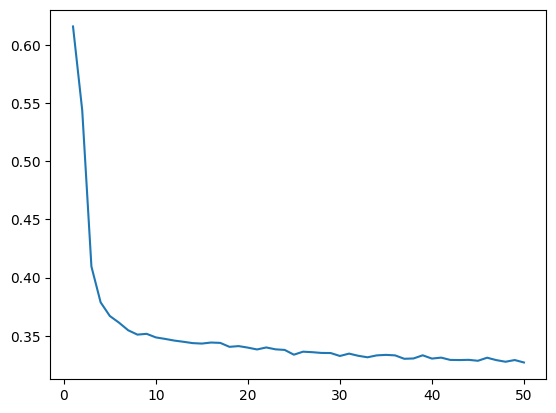

In [49]:
from torch.utils.data import TensorDataset
X = torch.tensor(df_encoded.drop('income', axis=1).values, dtype=torch.float32)
y = torch.tensor(df_encoded[['income']].values, dtype=torch.float32)
x_shape = df_encoded.shape[1]
dataset = TensorDataset(X, y)
print(dataset)
dataloader = DataLoader(dataset, batch_size=1024, shuffle=True)
print(dataloader)
device = 'cpu'
model = NNetModel_noEmb(x_shape=x_shape, layers=3).to(device)

# criteria = nn.CrossEntropyLoss()
criteria = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)

epochs = 50
loss_evol = []

for epoch in range(epochs):
    model.train()
    train_mse = []
    for xi, yi in dataloader:
        yhat = model(xi)
        loss = criteria(yhat, yi.flatten())
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        train_mse.append(loss.item())
    loss_evol.append(np.mean(train_mse))
    print(f'Epoch {epoch+1}: loss={np.mean(train_mse)}')

plt.plot(range(1,epochs+1), loss_evol)
    

[5.1370446e-02 2.7871266e-01 1.7493093e-02 ... 3.4680557e-02 2.4651544e-04
 9.8535478e-01]


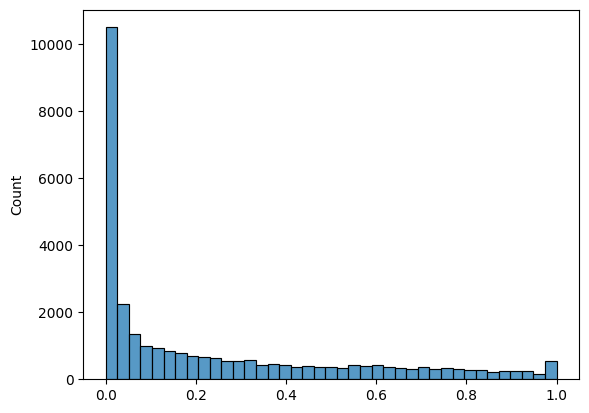

Farthest from random guess -> Best threshold = 0.20552121102809906
Nearest perfect model -> Best threshold = 0.27549025416374207


/tmp/ipykernel_6746/695770730.py:17: RuntimeWarning: invalid value encountered in sqrt
  geom_dist = np.sqrt((1-tpr)**2 - fpr**2)


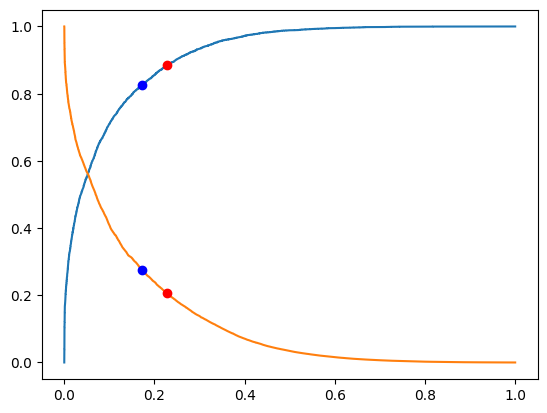

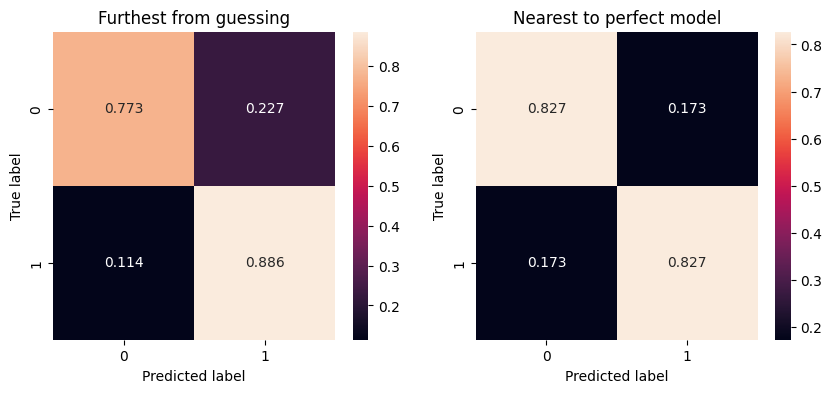

In [50]:
model.eval()
X = torch.tensor(df_encoded.drop('income', axis=1).values, dtype=torch.float32)
with torch.no_grad():
    yhat = model(X).numpy()

print(yhat)
sns.histplot(yhat)
plt.show()

fpr, tpr, thr = sklearn.metrics.roc_curve(y_true=df_encoded['income'], y_score=yhat)

J = tpr - fpr
idx = np.argmax(J)
best_thr = thr[idx]
print(f"Farthest from random guess -> Best threshold = {best_thr}")

geom_dist = np.sqrt((1-tpr)**2 - fpr**2)
idx_2 = np.argmax(geom_dist)
best_thr_2 = thr[idx_2]
print(f"Nearest perfect model -> Best threshold = {best_thr_2}")

plt.plot(fpr, tpr)
plt.plot(fpr, thr)
plt.plot(fpr[idx], tpr[idx],'ro')
plt.plot(fpr[idx], thr[idx],'ro')
plt.plot(fpr[idx_2], tpr[idx_2],'bo')
plt.plot(fpr[idx_2], thr[idx_2],'bo')
plt.show()

thresh = 0.2
yhat_J = []
yhat_geom_dist = []
for i in range(yhat.shape[0]):
    if yhat[i]>=best_thr:
        yhat_J.append(1)
    else:
        yhat_J.append(0)
    if yhat[i]>=best_thr_2:
        yhat_geom_dist.append(1)
    else:
        yhat_geom_dist.append(0)

cm_J = sklearn.metrics.confusion_matrix(y_true=df_encoded['income'], y_pred=yhat_J, normalize='true')
cm_geom_dist = sklearn.metrics.confusion_matrix(y_true=df_encoded['income'], y_pred=yhat_geom_dist, normalize='true')
fig, axs = plt.subplots(1,2, figsize=(10,4))
# sns.heatmap(cm, annot=True, fmt=':.2f', ax=axs)
sns.heatmap(cm_J, annot=True, ax=axs[0], fmt='.3f')
axs[0].set_title('Furthest from guessing')
sns.heatmap(cm_geom_dist, annot=True, ax=axs[1], fmt='.3f')
axs[1].set_title('Nearest to perfect model')
for i in range(2):
    axs[i].set_ylabel('True label')
    axs[i].set_xlabel('Predicted label')


## d) Conclusiones finales (2 puntos)

- Elaborar una tabla comparativa con los resultados obtenidos por ambos modelos.
- Redactar sus observaciones y apreciaciones derivadas de la comparación y plantear conclusiones fundamentadas respecto al desempeño de cada enfoque, justificando por qué uno funciona mejor o peor según las características del problema.